In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv("Bank_Customer_Churn.csv")

In [3]:
data.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42.0,2,0.00,1,1,1.0,101348.88,1
1,15647311,608,Spain,Female,41.0,1,83807.86,1,0,1.0,112542.58,0
2,15619304,502,France,Female,42.0,8,159660.80,3,1,0.0,113931.57,1
3,15701354,699,France,Female,39.0,1,0.00,2,0,0.0,93826.63,0
4,15737888,850,Spain,Female,43.0,2,125510.82,1,1,1.0,79084.10,0


In [4]:
data.shape

(10000, 12)

#### 1.Fill all missing values in the Country column with the name of the country in which you are currently residing.

In [5]:
data.isnull().sum()

customer_id            0
credit_score           0
country              999
gender               998
age                  993
tenure                 0
balance             1018
products_number        0
credit_card            0
active_member       1028
estimated_salary    1012
churn                  0
dtype: int64

In [6]:
data["country"] = data["country"].fillna("India")

In [7]:
data.isnull().sum()

customer_id            0
credit_score           0
country                0
gender               998
age                  993
tenure                 0
balance             1018
products_number        0
credit_card            0
active_member       1028
estimated_salary    1012
churn                  0
dtype: int64

#### 2.Identify the total number of female records in the dataset. Compare the count of males and females, and fill all missing values in the Gender column with the gender that has the higher count.

In [8]:
data["gender"].unique()

array(['Female', 'Male', nan], dtype=object)

In [9]:
data["gender"].value_counts()

gender
Male      4922
Female    4080
Name: count, dtype: int64

In [10]:
data["gender"] = data["gender"].fillna("Male")

#### 3.Analyze the Age column, calculate the average age, and fill all missing age values using this average. Ensure that the age values are stored as integers (no decimal values)

In [11]:
data.head(2)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42.0,2,0.00,1,1,1.0,101348.88,1
1,15647311,608,Spain,Female,41.0,1,83807.86,1,0,1.0,112542.58,0


In [12]:
data["age"].mean().round()

np.float64(39.0)

In [13]:
data["age"] = data["age"].fillna(data["age"].mean().round())

#### 4.Handle missing values in the Balance column as follows: Fill the first 500 missing values with the average balance, Fill the next 500 missing values with the maximum balance,Fill the remaining missing values with 0. Ensure the balance values contain exactly 2 decimal places.

In [14]:
data.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42.0,2,0.00,1,1,1.0,101348.88,1
1,15647311,608,Spain,Female,41.0,1,83807.86,1,0,1.0,112542.58,0
2,15619304,502,France,Female,42.0,8,159660.80,3,1,0.0,113931.57,1
3,15701354,699,France,Female,39.0,1,0.00,2,0,0.0,93826.63,0
4,15737888,850,Spain,Female,43.0,2,125510.82,1,1,1.0,79084.10,0


In [15]:
avg_balance = data["balance"].mean()
avg_balance

np.float64(76555.61364952126)

In [16]:
max_balance = data["balance"].max()
max_balance

250898.09

In [17]:
data["balance"].isnull().sum()

np.int64(1018)

In [18]:
missing_index = data[data["balance"].isnull()].index
missing_index

Index([  36,   42,   63,   71,   73,   76,   98,  103,  121,  131,
       ...
       9903, 9907, 9909, 9913, 9922, 9925, 9929, 9959, 9972, 9974],
      dtype='int64', length=1018)

In [21]:
data.loc[missing_index[:500], "balance"] = avg_balance

In [22]:
data.loc[missing_index[500:1000], "balance"] = max_balance

In [23]:
data.loc[missing_index[1000:], "balance"] = 0

In [24]:
data["balance"] = data["balance"].round(2)

In [25]:
data["balance"].isnull().sum()

np.int64(0)

#### 5.For the Active_Member column, fill missing values such that 50% of them are assigned 1 (active) and the remaining 50% are assigned 0 (inactive).

In [26]:
data["active_member"].isnull().sum()

np.int64(1028)

In [27]:
1028/2

514.0

In [28]:
data["active_member"].unique()

array([ 1.,  0., nan])

In [31]:
missing_active = data[data["active_member"].isnull()].index
missing_active

Index([  10,   20,   21,   24,   33,   34,   43,   56,   64,   67,
       ...
       9961, 9965, 9971, 9972, 9976, 9981, 9984, 9985, 9990, 9996],
      dtype='int64', length=1028)

In [33]:
data.loc[missing_active[:514], "active_member"] = 1

In [34]:
data.loc[missing_active[514:], "active_member"] = 0

In [35]:
data["active_member"].isnull().sum()

np.int64(0)

#### 6.Calculate the average value of the Estimated_Salary column and fill all missing salary values with this average, ensuring the values have exactly 2 decimal places.

In [36]:
avg_salary = data["estimated_salary"].mean().round(2)
avg_salary

np.float64(100162.82)

In [37]:
data["estimated_salary"] = data["estimated_salary"].fillna(avg_salary)

In [38]:
data["estimated_salary"].isnull().sum()

np.int64(0)

#### 7.After completing all the data cleaning steps, split the final cleaned dataset into two CSV files and export them.

In [43]:
Account_Fact = data[["customer_id", "credit_score", "balance", "products_number", "credit_card", "active_member", "estimated_salary", "churn"]]

In [46]:
Customer_Dim = data[["customer_id", "country", "gender", "age", "tenure"]]

In [106]:
Account_Fact.to_csv("Account_Fact.csv", index=False)
Customer_Dim.to_csv("Customer_Dim.csv", index=False)

In [107]:
Account_Fact2 = data[["customer_id", "credit_score", "balance", "age", "products_number", "credit_card", "active_member", "estimated_salary", "churn"]]

In [112]:
Account_Fact2.to_csv("Account_Fact2.csv", index=False)

# ML

In [113]:
data2 = pd.read_csv("Account_Fact2.csv")

In [114]:
data2

,customer_id,credit_score,balance,age,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,0.00,42.0,1,1,1.0,101348.88,1
1,15647311,608,83807.86,41.0,1,0,1.0,112542.58,0
2,15619304,502,159660.80,42.0,3,1,0.0,113931.57,1
3,15701354,699,0.00,39.0,2,0,0.0,93826.63,0
4,15737888,850,125510.82,43.0,1,1,1.0,79084.10,0
...,...,...,...,...,...,...,...,...,...
9995,15606229,771,0.00,39.0,2,1,0.0,96270.64,0
9996,15569892,516,57369.61,35.0,1,1,0.0,101699.77,0
9997,15584532,709,0.00,36.0,1,0,1.0,42085.58,1
9998,15682355,772,75075.31,42.0,2,1,0.0,92888.52,1


#### Q1. Load the cleaned Bank Customer dataset. Identify the Type of ML Problem. Select 'Churn' as target variable, and print the shape of X and y. 

In [115]:
x = data2.drop("churn", axis=1)

In [116]:
y = data2["churn"]

In [117]:
print("Shape of x", x.shape)
print("Shape of y", y.shape)

Shape of x (10000, 8)
Shape of y (10000,)


#### Q2. Identify categorical columns, apply Encoding techniques (if necessary, perform Standard Scaling on numerical features. 

In [118]:
data2.dtypes

customer_id           int64
credit_score          int64
balance             float64
age                 float64
products_number       int64
credit_card           int64
active_member       float64
estimated_salary    float64
churn                 int64
dtype: object

In [119]:
data2.describe()

,customer_id,credit_score,balance,age,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,85134.937180,38.891300,1.530200,0.70550,0.512000,100162.821259,0.203700
std,7.193619e+04,96.653299,70350.098454,9.936607,0.581654,0.45584,0.499881,54553.390897,0.402769
min,1.556570e+07,350.000000,0.000000,18.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,0.000000,32.000000,1.000000,0.00000,0.000000,56290.632500,0.000000
50%,1.569074e+07,652.000000,97328.050000,38.000000,1.000000,1.00000,1.000000,100162.820000,0.000000
75%,1.575323e+07,718.000000,130806.562500,43.000000,2.000000,1.00000,1.000000,143890.020000,0.000000
max,1.581569e+07,850.000000,250898.090000,92.000000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [120]:
from sklearn.preprocessing import StandardScaler

In [121]:
x_scaler = StandardScaler()

In [122]:
x = x_scaler.fit_transform(x)

#### Q.3.Plot churn distribution. Analyze the relationship between CreditScore, Age, and Balance with churn

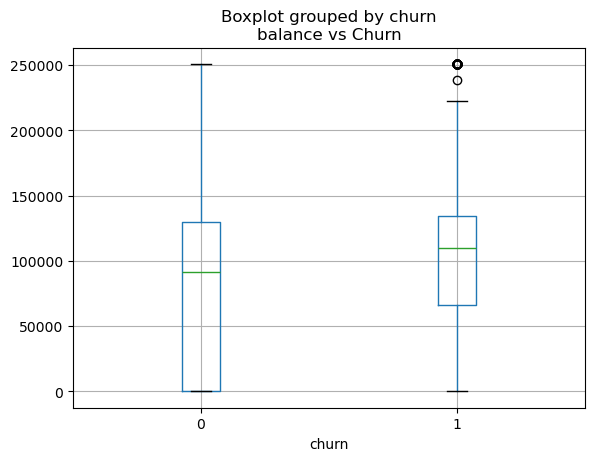

In [123]:
data.boxplot(column="balance", by="churn")
plt.title("balance vs Churn")
plt.show()

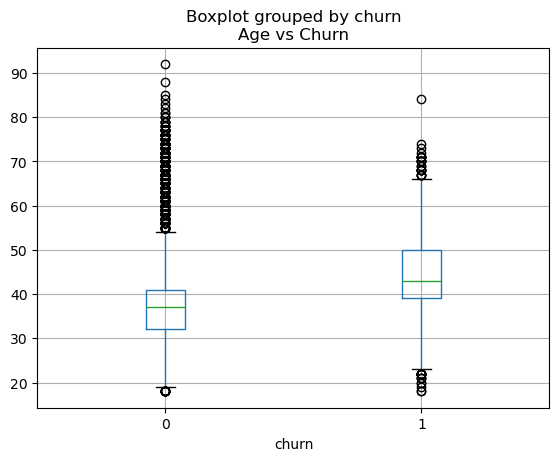

In [124]:
data.boxplot(column="age", by="churn")
plt.title("Age vs Churn")
plt.show()

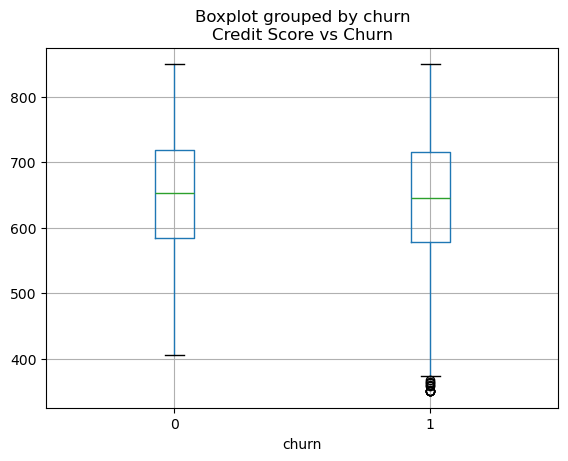

In [125]:
data.boxplot(column="credit_score", by="churn")
plt.title("Credit Score vs Churn")
plt.show()

#### Q.4 Split the dataset into training and testing sets. Train a SVM model and display accuracy Score, Confusion Matrix, Classification Report.. 

In [126]:
from sklearn.model_selection import train_test_split

In [127]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7, random_state=42)

In [128]:
from sklearn.svm import SVC

In [129]:
model = SVC()

In [130]:
model.fit(x_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [131]:
y_pre = model.predict(x_test)

In [132]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [133]:
accuracy_score(y_test, y_pre)*100

85.46666666666667

In [134]:
hit = confusion_matrix(y_test, y_pre)
hit

array([[2364,   52],
       [ 384,  200]])

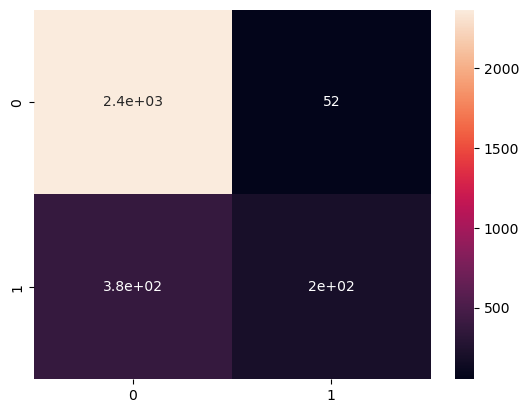

In [135]:
sns.heatmap(hit, annot=True);

In [136]:
print(classification_report(y_test, y_pre))

              precision    recall  f1-score   support

           0       0.86      0.98      0.92      2416
           1       0.79      0.34      0.48       584

    accuracy                           0.85      3000
   macro avg       0.83      0.66      0.70      3000
weighted avg       0.85      0.85      0.83      3000



#### Q5. Train a Random Forest Classifier on the same data and predict Churn,find - accuracy Score, Confusion Matrix, Classification Report.

In [137]:
from sklearn.ensemble import RandomForestClassifier

In [138]:
model2 = RandomForestClassifier()

In [139]:
model2.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [140]:
model_pre = model2.predict(x_test)
model_pre

array([0, 0, 0, ..., 0, 0, 0], shape=(3000,))

In [141]:
accuracy_score(y_test, model_pre)*100

85.3

In [142]:
h = confusion_matrix(y_test, model_pre)
h

array([[2331,   85],
       [ 356,  228]])

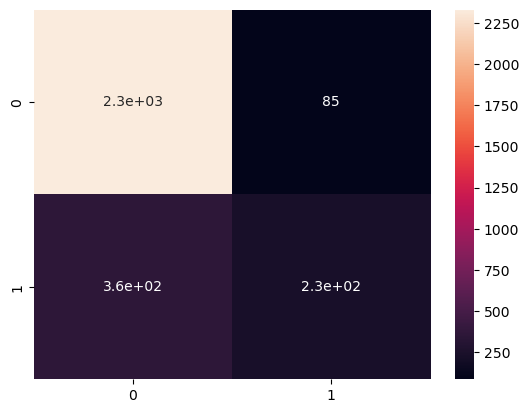

In [143]:
sns.heatmap(h, annot=True);

In [144]:
print(classification_report(y_test, model_pre))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91      2416
           1       0.73      0.39      0.51       584

    accuracy                           0.85      3000
   macro avg       0.80      0.68      0.71      3000
weighted avg       0.84      0.85      0.83      3000

